# Training Log Tracker

Parse BiaPy partitioned SLURM train `.out` logs into a DataFrame and plot metrics across partitions (`BiaPy/biapy_train_track.py`).

In [1]:
import os
import sys
from pathlib import Path

root = Path.cwd()
if root.name == "ipynb":
    root = root.parent
    os.chdir(root)
print(root)

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import pandas as pd

from BiaPy.biapy_train_track import (
    consolidate_training_log,
    plot_training_across_partitions,
)

/scratch/wmz2007/neuroinfo_fruitfly


## Load training log

Point `LOG_PATH` at a SLURM train `.out` under `sbatch/biapy/`.

In [3]:
LOG_PATH = Path(
    # "sbatch/biapy/BiaPy-py-biapy-v1-channel-rot-train-15516540.out"
    "sbatch/biapy/BiaPy-py-biapy-v1-no-aug-train-15450036.out"
)

df = consolidate_training_log(LOG_PATH)
print(
    f"{len(df)} epoch(s) across "
    f"{df['partition'].nunique() if not df.empty else 0} partition(s)"
)
df.head()

30 epoch(s) across 1 partition(s)


,partition,epoch,global_step,train_loss,val_loss,train_iou_f,train_iou_c,train_l1_db,train_l1_dn,val_iou_f,val_iou_c,val_l1_db,val_l1_dn,lr,early_stopped
0,0,1,0,2.6213,1.8690,0.0019,0.0019,0.5223,0.4511,0.0038,0.0038,0.3921,0.3319,0.000207,False
1,0,2,1,1.6827,1.4643,0.0032,0.0049,0.3263,0.3554,0.0103,0.0114,0.2443,0.3800,0.000457,False
2,0,3,2,1.2855,1.1357,0.0230,0.0193,0.2379,0.3778,0.0615,0.0035,0.2866,0.3986,0.000841,False
3,0,4,3,0.9052,0.7403,0.0851,0.0472,0.2781,0.4036,0.1408,0.0849,0.3070,0.4270,0.001312,False
4,0,5,4,0.5931,0.5467,0.1551,0.1607,0.3026,0.4395,0.2178,0.1335,0.3272,0.4273,0.001812,False


## Plot across partitions

X-axis is `global_step` (epochs concatenated across partitions). Dashed vertical lines mark partition boundaries.

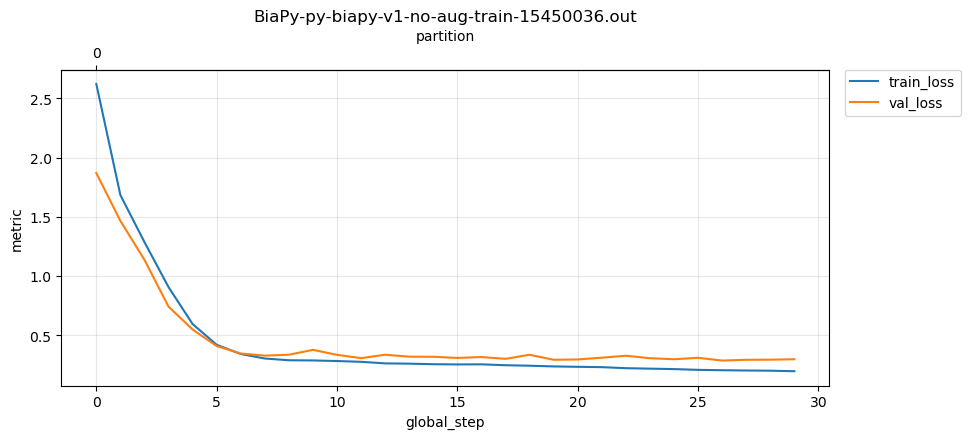

In [4]:
fig = plot_training_across_partitions(
    df,
    metrics=("train_loss", "val_loss"),
    # Avail metrics: train_iou_f,train_iou_c,train_l1_db,train_l1_dn,val_iou_f,val_iou_c,val_l1_db,val_l1_dn,lr,early_stopped
    title=LOG_PATH.name,
)
plt.show()

## Optional: other metrics

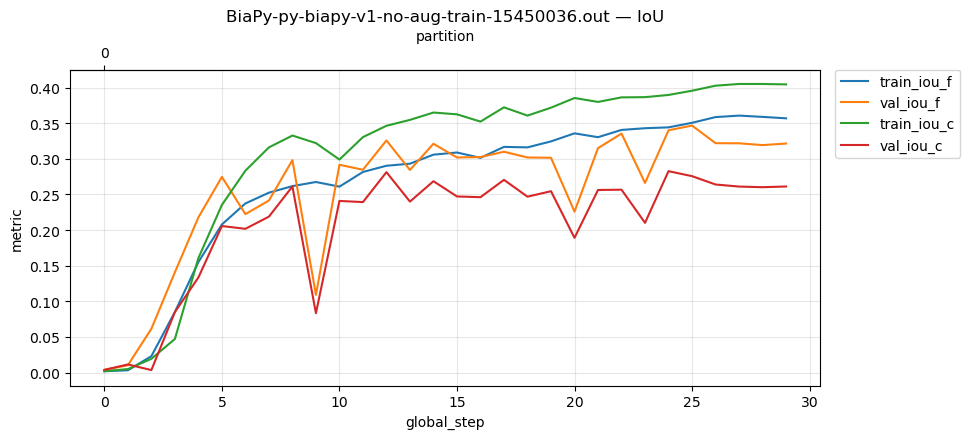

In [5]:
fig = plot_training_across_partitions(
    df,
    metrics=("train_iou_f", "val_iou_f", "train_iou_c", "val_iou_c"),
    title=f"{LOG_PATH.name} — IoU",
)
plt.show()

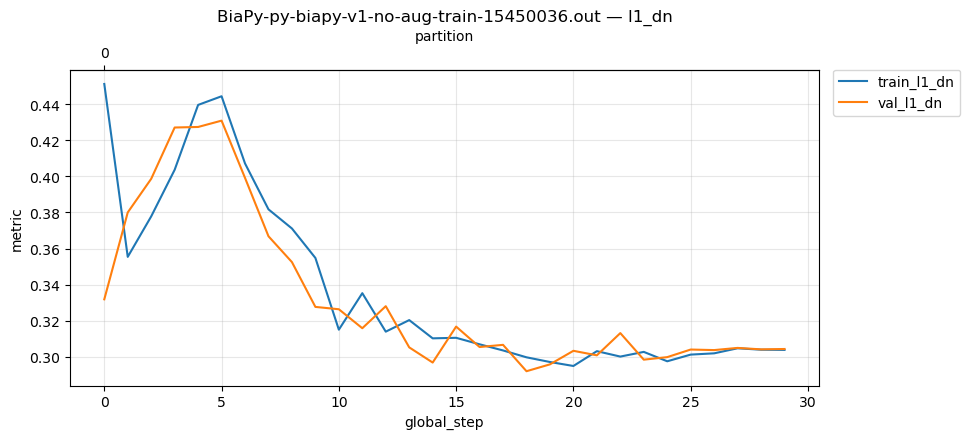

In [6]:
fig = plot_training_across_partitions(
    df,
    # train_l1_db,train_l1_dn, val_l1_db,val_l1_dn,lr
    metrics=(
        # "train_l1_db", 
        # "val_l1_db", 
        "train_l1_dn", 
        "val_l1_dn"
    ),
    title=f"{LOG_PATH.name} — l1_dn",
)
plt.show()

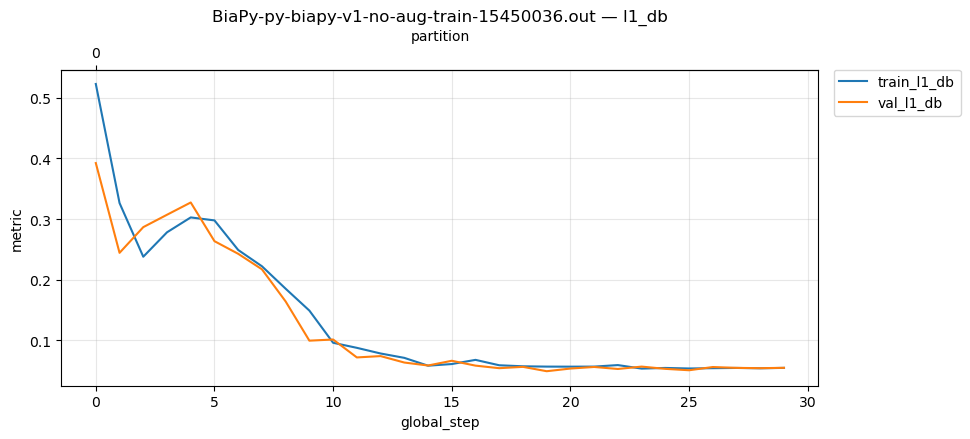

In [7]:
fig = plot_training_across_partitions(
    df,
    # train_l1_db,train_l1_dn, val_l1_db,val_l1_dn,lr
    metrics=(
        "train_l1_db", 
        "val_l1_db", 
        # "train_l1_dn", 
        # "val_l1_dn"
    ),
    title=f"{LOG_PATH.name} — l1_db",
)
plt.show()

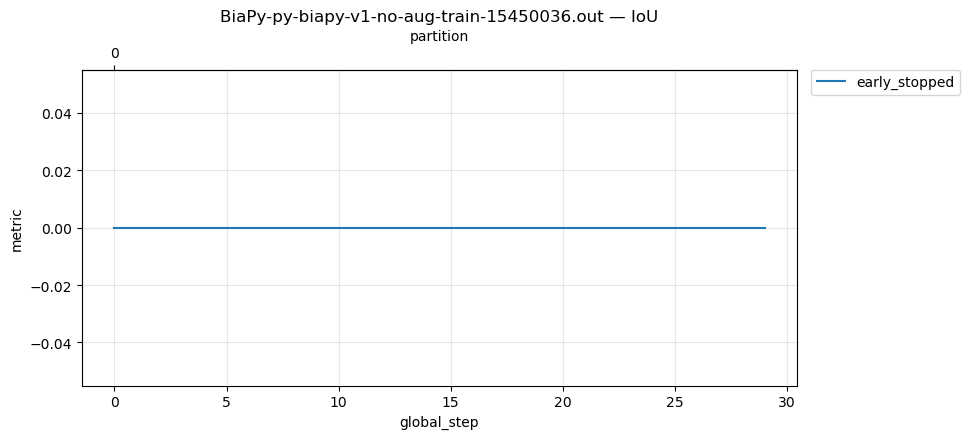

In [8]:
fig = plot_training_across_partitions(
    df,
    # lr
    metrics=([
        # "lr",
        "early_stopped"
    ]),
    title=f"{LOG_PATH.name} — IoU",
)
plt.show()